In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer  # Importa PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt  



# Caricare i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Stampa i nomi delle colonne per verificare
#print("Colonne nel DataFrame:", data.columns)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])  # Rimuovi filename e label
y = data['label']  # Etichette

# Suddividere il dataset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]


60


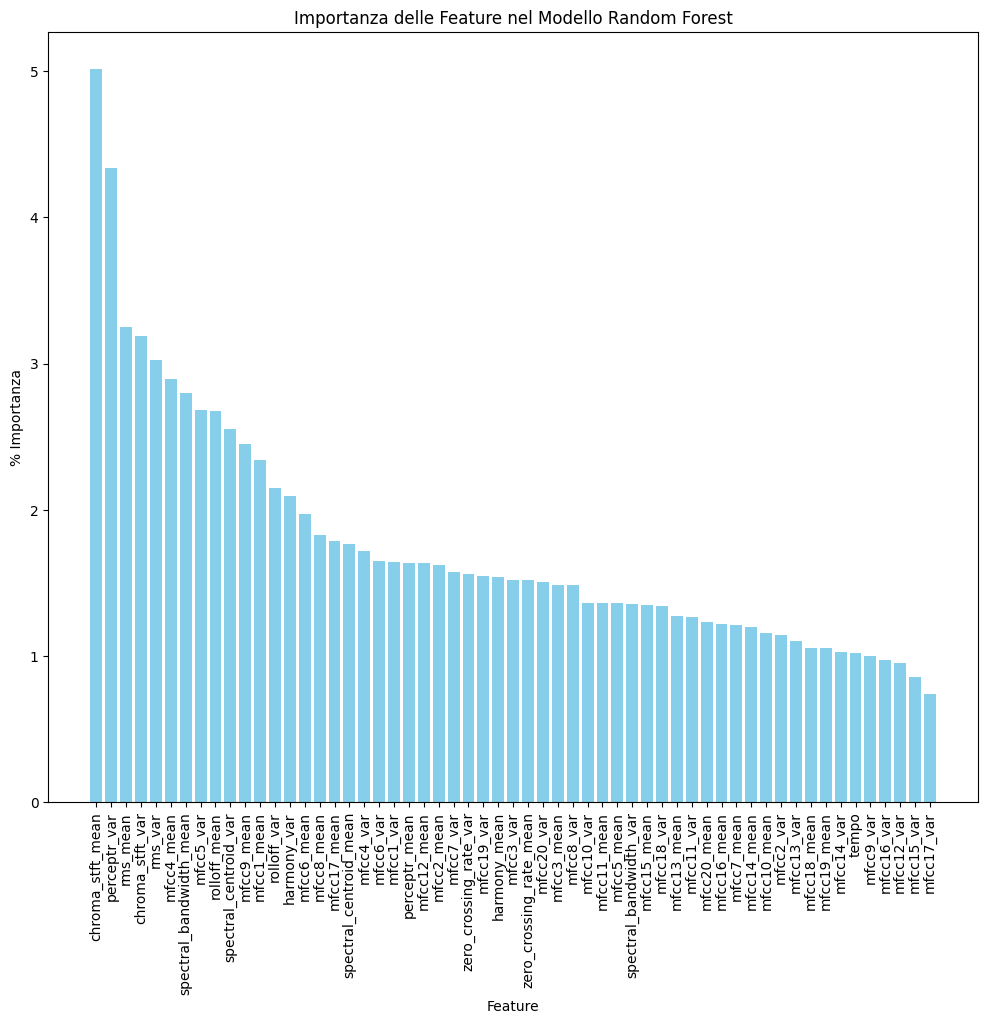

In [7]:
# Assicurati di non includere colonne non numeriche nel set di feature
X = data.drop(columns=['label', 'filename', 'length'])  # Rimuovi 'filename' e 'label'
y = data['label']


colonne=data.columns.size
print(colonne)

# Converti le etichette in numerico se necessario
y = y.astype('category').cat.codes  # Converte le etichette in numeri

# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Modello Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Importanza delle feature
importances = rf.feature_importances_ * 100

# Creare un DataFrame per visualizzare l'importanza delle feature
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Grafico a barre verticale dell'importanza delle feature
plt.figure(figsize=(12, 10))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xticks(rotation=90)  # Ruota le etichette delle feature per leggibilità
plt.xlabel('Feature')
plt.ylabel('% Importanza')
plt.title('Importanza delle Feature nel Modello Random Forest')
plt.show()


senza nulla

In [11]:

model=RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0) 
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)

    # Calcolare metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
print(f'Accuratezza: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'F2-score: {f2:.4f}')
print('------------------------------------------------------------')

Accuratezza: 0.7650
Precision: 0.7753
Recall: 0.7796
F1-score: 0.7734
F2-score: 0.7760
------------------------------------------------------------


In [12]:
for scaler in scalers:

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Definizione del modello di Logistic Regression
    model = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0) 
    model.fit(X_train, y_train)

    # Valutazione del modello
    y_pred = model.predict(X_test)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'Scaler: {scaler.__class__.__name__}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    print('------------------------------------------------------------')

Scaler: RobustScaler
Accuratezza: 0.7650
Precision: 0.7765
Recall: 0.7822
F1-score: 0.7748
F2-score: 0.7780
------------------------------------------------------------
Scaler: StandardScaler
Accuratezza: 0.7650
Precision: 0.7765
Recall: 0.7822
F1-score: 0.7748
F2-score: 0.7780
------------------------------------------------------------
Scaler: MinMaxScaler
Accuratezza: 0.7650
Precision: 0.7765
Recall: 0.7822
F1-score: 0.7748
F2-score: 0.7780
------------------------------------------------------------
Scaler: PowerTransformer
Accuratezza: 0.7650
Precision: 0.7719
Recall: 0.7825
F1-score: 0.7715
F2-score: 0.7765
------------------------------------------------------------


In [14]:
# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [50, 100],  # Numero di alberi nella foresta
    'max_depth': [10, 20, 30],  # Profondità massima di ciascun albero
    'min_samples_split': [2, 5, 10],  # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1, 2, 4],    # Minimo numero di campioni richiesti in una foglia
    'bootstrap': [True, False]        # Uso del bootstrap per campionare i dati
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuratezza: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Migliori iperparametri trovati: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuratezza: 0.7700
Precision: 0.7707
Recall: 0.7829
F1-score: 0.7705


In [ ]:
# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [100,150,200],      # Numero di alberi nella foresta
    'max_depth': [30,35,40,50],          # Profondità massima di ciascun albero
    'min_samples_split': [2,3,4],       # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1],         # Minimo numero di campioni richiesti in una foglia
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuratezza: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori iperparametri trovati: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuratezza: 0.7700
Precision: 0.7707
Recall: 0.7829
F1-score: 0.7705


In [8]:
for scaler in scalers:

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Definizione del modello di Logistic Regression
    model = RandomForestClassifier(bootstrap= False, max_depth= 30, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 100) 
    model.fit(X_train, y_train)

    # Valutazione del modello
    y_pred = model.predict(X_test)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'Scaler: {scaler.__class__.__name__}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    print('------------------------------------------------------------')

Scaler: RobustScaler
Accuratezza: 0.7650
Precision: 0.7648
Recall: 0.7737
F1-score: 0.7654
F2-score: 0.7695
------------------------------------------------------------
Scaler: StandardScaler
Accuratezza: 0.7950
Precision: 0.7979
Recall: 0.8076
F1-score: 0.7980
F2-score: 0.8025
------------------------------------------------------------
Scaler: MinMaxScaler
Accuratezza: 0.7900
Precision: 0.7972
Recall: 0.7981
F1-score: 0.7942
F2-score: 0.7957
------------------------------------------------------------
Scaler: PowerTransformer
Accuratezza: 0.7400
Precision: 0.7499
Recall: 0.7568
F1-score: 0.7441
F2-score: 0.7499
------------------------------------------------------------


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.model_selection import train_test_split
import pandas as pd

# Caricare i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le etichette
y = data['label']  # Etichette

# Colonne da rimuovere progressivamente
columns_to_remove = ['mfcc16_var','mfcc14_var', 'mfcc15_var', 'mfcc12_var']

# Scalers per standardizzare i dati
scalers = [RobustScaler(), StandardScaler(), MinMaxScaler(), PowerTransformer()]

# Iterare su ogni colonna da rimuovere
for column in columns_to_remove:
    # Creare un set di caratteristiche rimuovendo la colonna corrente
    X = data.drop(columns=['filename', 'label', column])  # Rimuovi la colonna attuale da testare
    print(f'\n--- Rimozione della colonna: {column} ---')
    
    # Suddividere il dataset in set di addestramento e test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Iterare sui diversi scalers
    for scaler in scalers:
        # Standardizzare le caratteristiche
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Definizione del modello di Random Forest
        model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
        model.fit(X_train_scaled, y_train)

        # Valutazione del modello
        y_pred = model.predict(X_test_scaled)

        # Calcolare metriche
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')

        # Stampare i risultati
        print(f'Scaler: {scaler.__class__.__name__}')
        print(f'Accuratezza: {accuracy:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'F1-score: {f1:.4f}')
        print(f'F2-score: {f2:.4f}')
        print('------------------------------------------------------------')



--- Rimozione della colonna: mfcc16_var ---
Scaler: RobustScaler
Accuratezza: 0.7800
Precision: 0.7936
Recall: 0.7950
F1-score: 0.7865
F2-score: 0.7894
------------------------------------------------------------
Scaler: StandardScaler
Accuratezza: 0.7700
Precision: 0.7729
Recall: 0.7845
F1-score: 0.7733
F2-score: 0.7786
------------------------------------------------------------
Scaler: MinMaxScaler
Accuratezza: 0.7550
Precision: 0.7602
Recall: 0.7684
F1-score: 0.7597
F2-score: 0.7638
------------------------------------------------------------
Scaler: PowerTransformer
Accuratezza: 0.6550
Precision: 0.6549
Recall: 0.6580
F1-score: 0.6510
F2-score: 0.6539
------------------------------------------------------------

--- Rimozione della colonna: mfcc14_var ---
Scaler: RobustScaler
Accuratezza: 0.7700
Precision: 0.7801
Recall: 0.7771
F1-score: 0.7692
F2-score: 0.7713
------------------------------------------------------------
Scaler: StandardScaler
Accuratezza: 0.7950
Precision: 0.801


--- Rimozione della colonna: mfcc16_var ---
Accuratezza: 0.7750
Precision: 0.7712
Recall: 0.7900
F1-score: 0.7744
F2-score: 0.7822
------------------------------------------------------------
Accuratezza: 0.7500
Precision: 0.7511
Recall: 0.7603
F1-score: 0.7496
F2-score: 0.7544
------------------------------------------------------------
Accuratezza: 0.8000
Precision: 0.8033
Recall: 0.8114
F1-score: 0.8032
F2-score: 0.8070
------------------------------------------------------------
Accuratezza: 0.6700
Precision: 0.6792
Recall: 0.6760
F1-score: 0.6676
F2-score: 0.6701
------------------------------------------------------------

--- Rimozione della colonna: mfcc14_var ---
Accuratezza: 0.7800
Precision: 0.7823
Recall: 0.7913
F1-score: 0.7830
F2-score: 0.7871
------------------------------------------------------------
Accuratezza: 0.7650
Precision: 0.7685
Recall: 0.7743
F1-score: 0.7676
F2-score: 0.7706
------------------------------------------------------------
Accuratezza: 0.7750
Pr

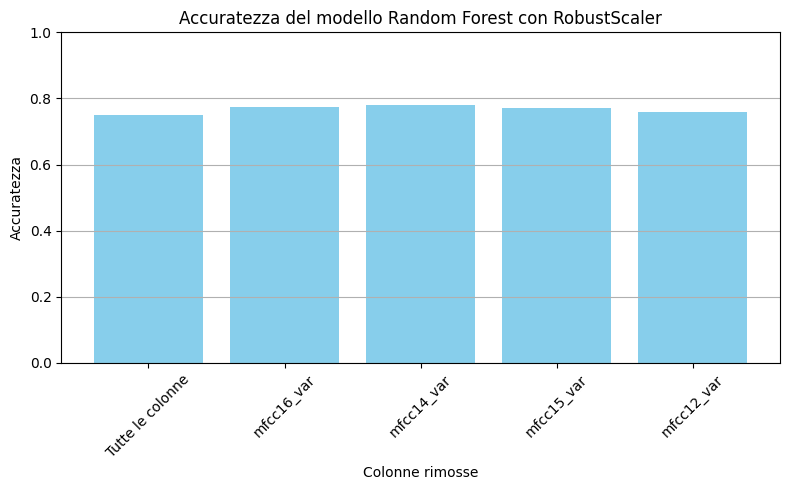

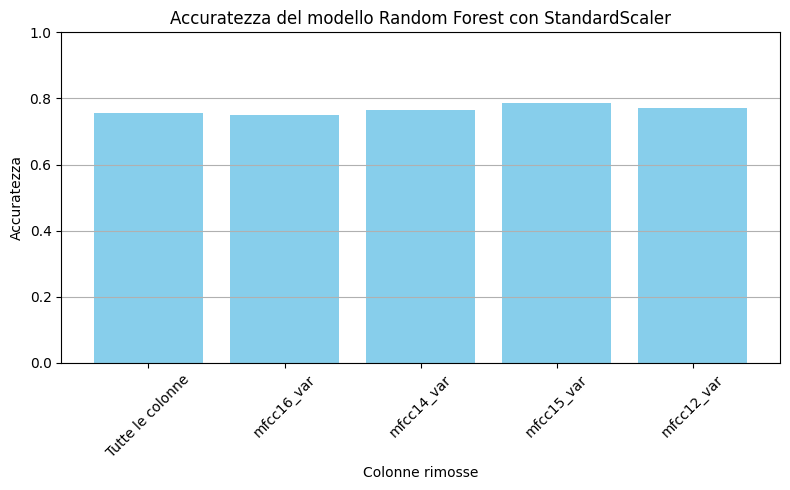

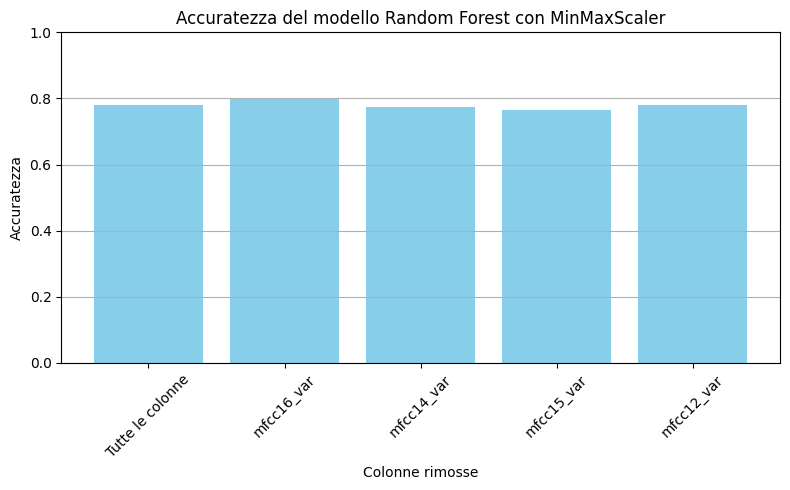

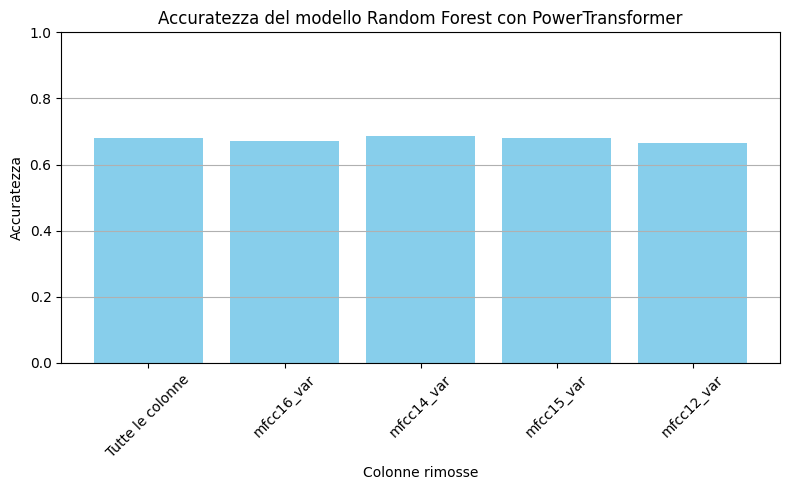

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.model_selection import train_test_split

# Caricare i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le etichette
y = data['label']  # Etichette

# Colonne da rimuovere progressivamente
columns_to_remove = ['mfcc16_var','mfcc14_var', 'mfcc15_var', 'mfcc12_var']

# Scalers per standardizzare i dati
scalers = [RobustScaler(), StandardScaler(), MinMaxScaler(), PowerTransformer()]
scaler_names = [scaler.__class__.__name__ for scaler in scalers]

# Memorizzare i risultati
results = {name: [] for name in scaler_names}

# Aggiungi un'iterazione per il caso senza rimuovere colonne
X_all = data.drop(columns=['filename', 'label'])  # Rimuovi solo filename e label

# Suddividere il dataset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Iterare sui diversi scalers per il caso senza rimuovere colonne
for scaler in scalers:
    # Standardizzare le caratteristiche
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Definizione del modello di Random Forest
    model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
    model.fit(X_train_scaled, y_train)

    # Valutazione del modello
    y_pred = model.predict(X_test_scaled)

    # Calcolare l'accuratezza
    accuracy = accuracy_score(y_test, y_pred)

    # Memorizzare il risultato per il caso senza rimuovere colonne
    results[scaler.__class__.__name__].append(accuracy)

# Iterare su ogni colonna da rimuovere
for column in columns_to_remove:
    # Creare un set di caratteristiche rimuovendo la colonna corrente
    X = data.drop(columns=['filename', 'label', column])  # Rimuovi la colonna attuale da testare
    print(f'\n--- Rimozione della colonna: {column} ---')
    
    # Suddividere il dataset in set di addestramento e test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Iterare sui diversi scalers
    for scaler in scalers:
        # Standardizzare le caratteristiche
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Definizione del modello di Random Forest
        model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
        model.fit(X_train_scaled, y_train)

        # Valutazione del modello
        y_pred = model.predict(X_test_scaled)

        # Calcolare l'accuratezza
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
        recall = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
        print(f'Accuratezza: {accuracy:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'F1-score: {f1:.4f}')
        print(f'F2-score: {f2:.4f}')
        print('------------------------------------------------------------')

        # Memorizzare il risultato
        results[scaler.__class__.__name__].append(accuracy)

# Creare un grafico a barre per ciascuno scaler
for scaler_name in scaler_names:
    plt.figure(figsize=(8, 5))
    plt.bar(['Tutte le colonne'] + columns_to_remove, results[scaler_name], color='skyblue')
    plt.title(f'Accuratezza del modello Random Forest con {scaler_name}')
    plt.xlabel('Colonne rimosse')
    plt.ylabel('Accuratezza')
    plt.ylim(0, 1)  # Imposta il limite dell'asse y da 0 a 1
    plt.xticks(rotation=45)  # Ruota le etichette per una migliore leggibilità
    plt.grid(axis='y')
    plt.tight_layout()  # Ottimizza il layout
    plt.show()


feature selection da 0 a n no standardizzati

Aggiunta feature: rms_mean, Accuratezza: 0.2250
Feature selezionate: ['rms_mean'], Numero di feature: 1


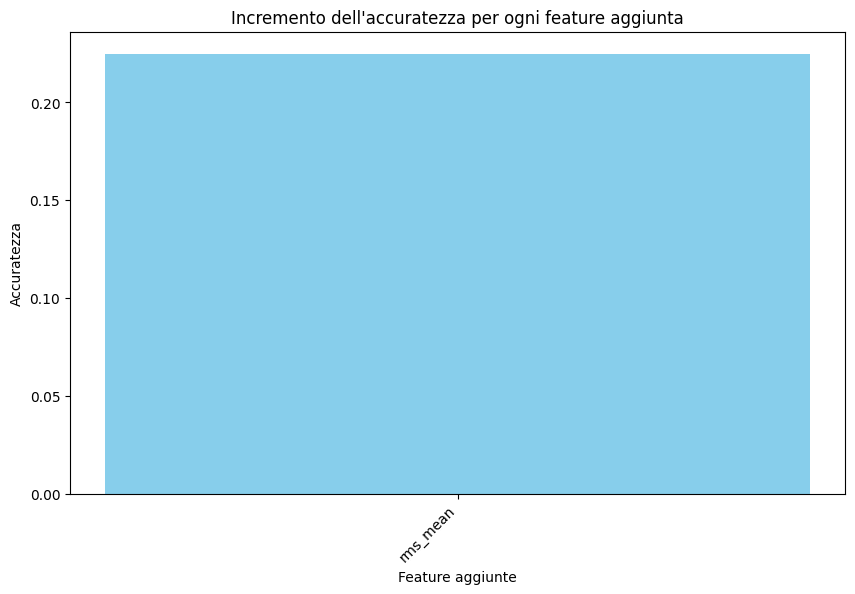

Aggiunta feature: perceptr_mean, Accuratezza: 0.3600
Feature selezionate: ['rms_mean', 'perceptr_mean'], Numero di feature: 2


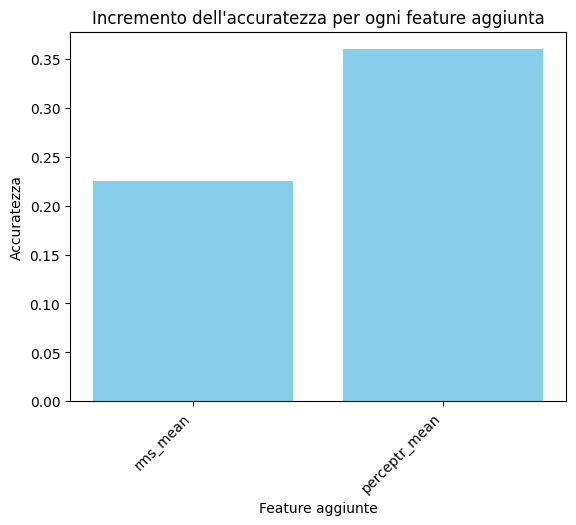

Aggiunta feature: rolloff_mean, Accuratezza: 0.4650
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean'], Numero di feature: 3


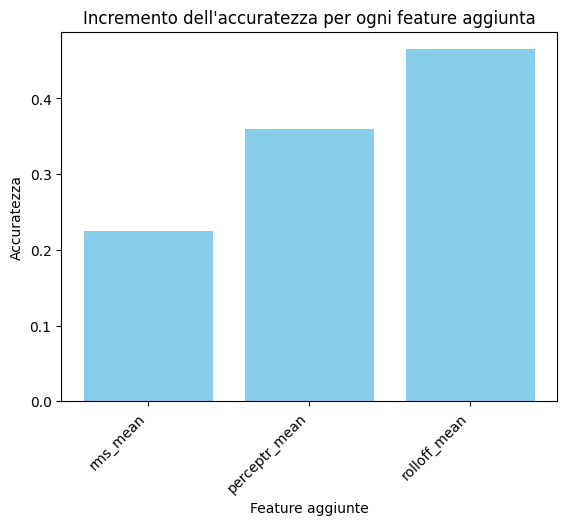

Aggiunta feature: rms_var, Accuratezza: 0.5100
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var'], Numero di feature: 4


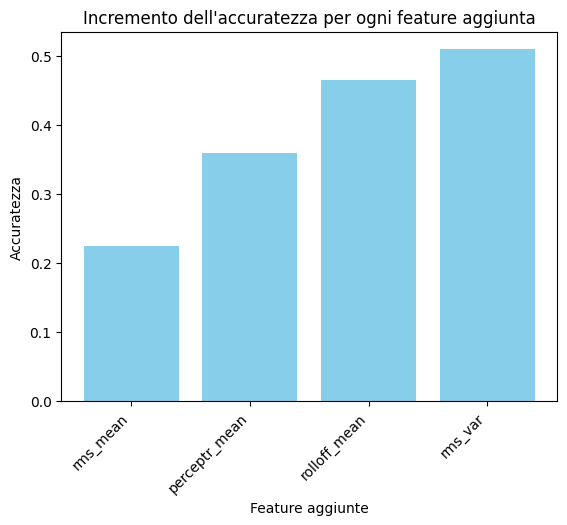

Aggiunta feature: mfcc13_mean, Accuratezza: 0.5850
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean'], Numero di feature: 5


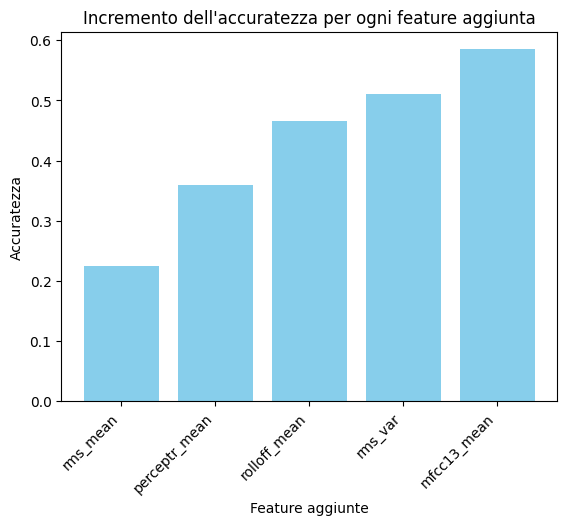

Aggiunta feature: mfcc11_mean, Accuratezza: 0.6100
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean', 'mfcc11_mean'], Numero di feature: 6


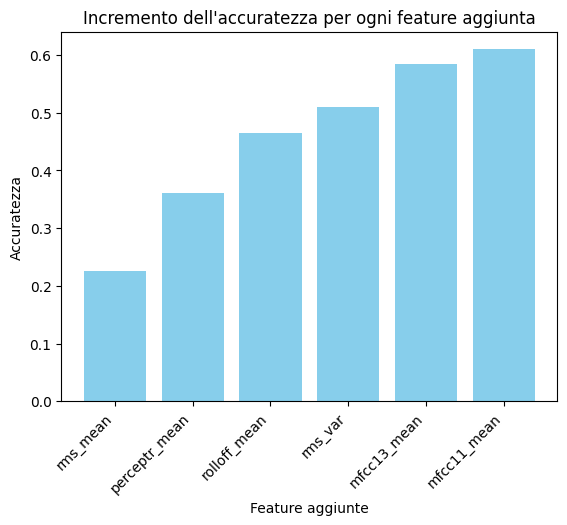

Aggiunta feature: mfcc15_mean, Accuratezza: 0.6400
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean', 'mfcc11_mean', 'mfcc15_mean'], Numero di feature: 7


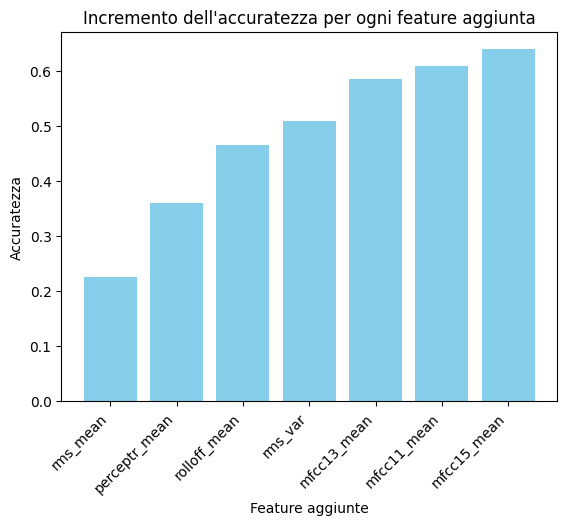

Aggiunta feature: harmony_mean, Accuratezza: 0.6450
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean', 'mfcc11_mean', 'mfcc15_mean', 'harmony_mean'], Numero di feature: 8


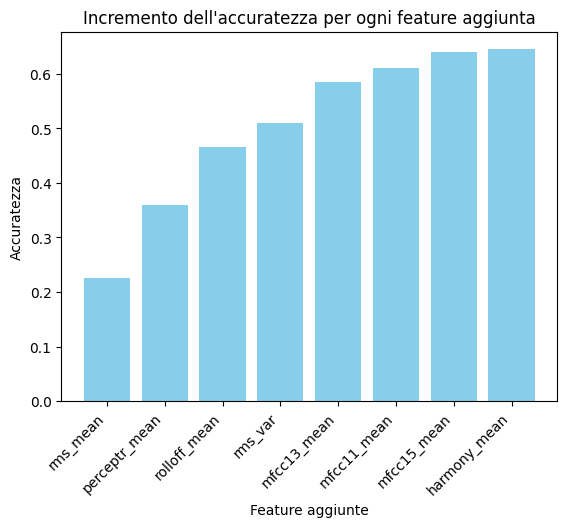

Aggiunta feature: mfcc3_mean, Accuratezza: 0.6800
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean', 'mfcc11_mean', 'mfcc15_mean', 'harmony_mean', 'mfcc3_mean'], Numero di feature: 9


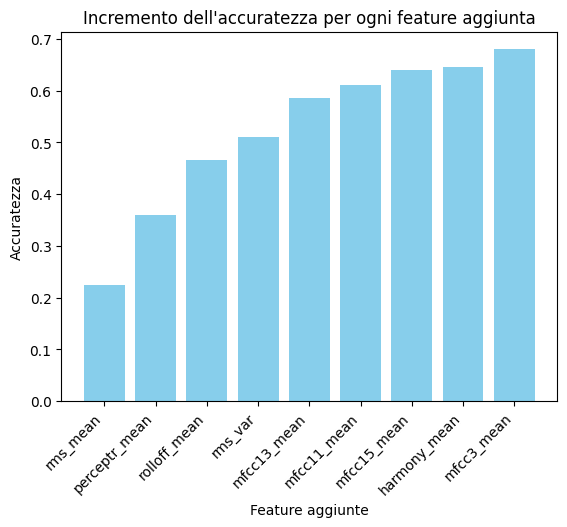

Aggiunta feature: mfcc5_mean, Accuratezza: 0.7000
Feature selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean', 'mfcc11_mean', 'mfcc15_mean', 'harmony_mean', 'mfcc3_mean', 'mfcc5_mean'], Numero di feature: 10


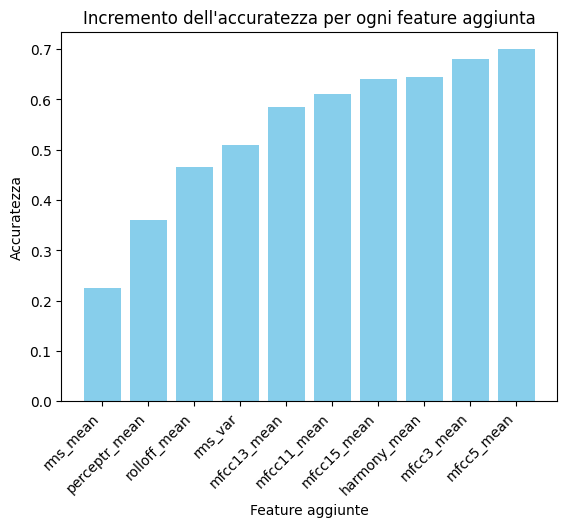


Feature finali selezionate: ['rms_mean', 'perceptr_mean', 'rolloff_mean', 'rms_var', 'mfcc13_mean', 'mfcc11_mean', 'mfcc15_mean', 'harmony_mean', 'mfcc3_mean', 'mfcc5_mean']
Accuratezza finale: 0.7


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Carica i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label', 'length'])
y = data['label']

scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Suddividere il dataset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inizializza le variabili
selected_features = []
remaining_features = list(X.columns)
best_accuracy = 0.0

# Inizializza una lista per memorizzare le accuratezze per ogni nuova feature selezionata
accuracies_plot = []
features_plot = []

# Imposta il grafico
plt.figure(figsize=(10, 6))
plt.ion()  # Modalità interattiva per aggiornamenti dinamici

while remaining_features:
    accuracies = []
    
    # Prova ad aggiungere ogni feature rimanente
    for feature in remaining_features:
        # Crea un nuovo set di feature selezionando quelle attuali e la feature proposta
        current_features = selected_features + [feature]
        
        # Addestra il modello
        model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
        model.fit(X_train[current_features], y_train)
        
        # Valuta il modello
        y_pred = model.predict(X_test[current_features])
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append((feature, accuracy))
    
    # Trova la feature che migliora l'accuratezza
    best_feature, best_accuracy_current = max(accuracies, key=lambda x: x[1])
    
    # Se c'è un miglioramento, aggiungi la feature
    if best_accuracy_current > best_accuracy:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_accuracy = best_accuracy_current

        # Aggiorna la lista per il grafico
        accuracies_plot.append(best_accuracy)
        features_plot.append(best_feature)
        
        # Stampa le feature selezionate e l'accuratezza attuale
        print(f"Aggiunta feature: {best_feature}, Accuratezza: {best_accuracy:.4f}")
        print(f"Feature selezionate: {selected_features}, Numero di feature: {len(selected_features)}")

        # Aggiorna il grafico
        plt.clf()  # Cancella il grafico precedente
        plt.bar(features_plot, accuracies_plot, color='skyblue')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel("Feature aggiunte")
        plt.ylabel("Accuratezza")
        plt.title("Incremento dell'accuratezza per ogni feature aggiunta")
        plt.pause(0.5)  # Pausa per aggiornare la visualizzazione
    else:
        # Se non ci sono miglioramenti, esci dal ciclo
        break

plt.ioff()  # Disattiva la modalità interattiva
plt.show()  # Mostra il grafico finale

print("\nFeature finali selezionate:", selected_features)
print("Accuratezza finale:", best_accuracy)


con k-fold

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardizza le caratteristiche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
feature_importances_list = []  # Lista per le importanze delle feature

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.01)  # Imposta il valore di alpha
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]  # Indici delle feature selezionate
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Addestra il modello Random Forest
    model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
    model.fit(X_train_selected, y_train)

    # Valuta il modello
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Raccogli le importanze delle feature
    importances = model.feature_importances_
    
    # Seleziona solo le importanze delle feature che sono state effettivamente utilizzate
    feature_importances_list.append(importances[selected_features])  # Salva le importanze delle feature selezionate

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")

# Calcola la media delle importanze delle feature selezionate
mean_importances = np.mean(feature_importances_list, axis=0)

# Nomi delle feature selezionate
# Raccogli gli indici delle feature selezionate in base alla loro posizione originale
feature_names = X.columns[selected_features]  # Nomi delle feature selezionate
print(f"Feature selezionate: {len(selected_features)}")
print("Nomi delle feature selezionate:", feature_names)

# Grafico delle accuratezze
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature
plt.figure(figsize=(12, 6))
plt.barh(feature_names, mean_importances, color='teal')
plt.xlabel('Importanza Media')
plt.title('Importanza delle Feature Selezionate')
plt.show()


IndexError: index 48 is out of bounds for axis 0 with size 48

Accuratezza per ogni fold: [0.69, 0.73, 0.74, 0.7, 0.75, 0.75, 0.73, 0.78, 0.7, 0.72]
Accuratezza media dopo K-Fold: 0.7290

Feature selezionate dal Lasso: ['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc19_mean', 'mfcc20_mean', 'mfcc20_var']
Indice di feature selezionate: [ 0  1  2  3 

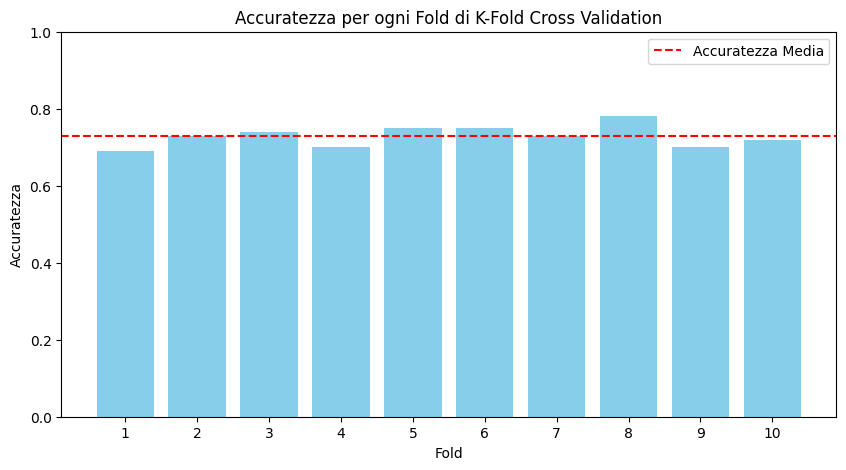

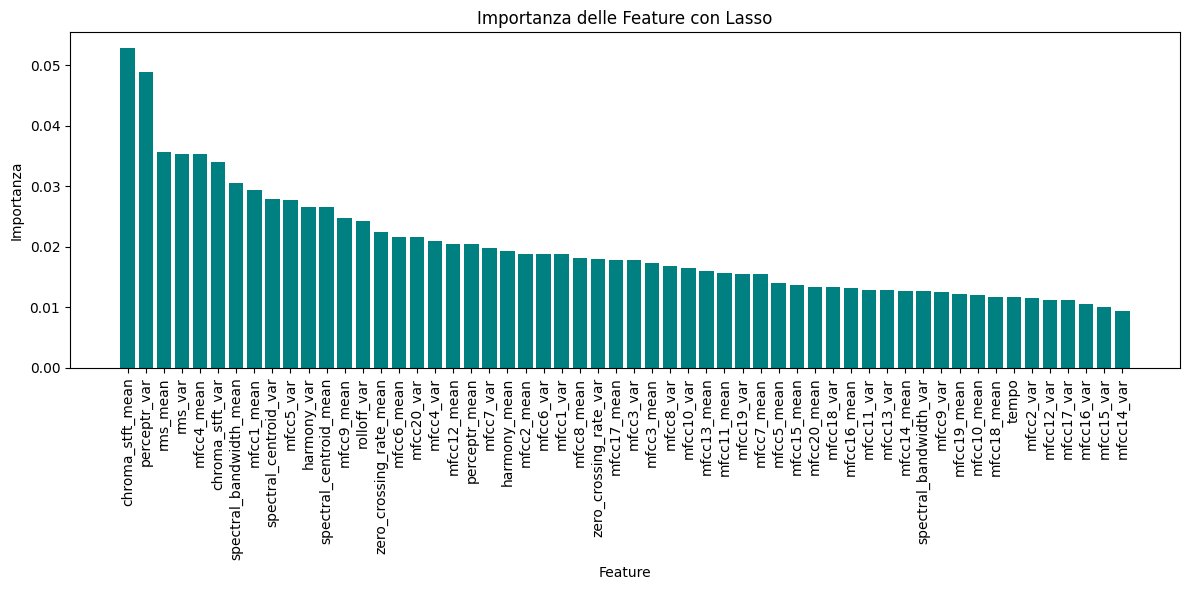

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label','length'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardizza le caratteristiche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
importances_dict = {}  # Dizionario per tracciare le importanze delle feature selezionate

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Addestra il modello Random Forest sulle feature selezionate
    model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
    model.fit(X_train_selected, y_train)

    # Calcolare l'importanza delle feature
    importances = model.feature_importances_
    
    # Salvare le importanze solo per le feature selezionate
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]  # Ottieni il nome della feature
        if feature_name in importances_dict:
            importances_dict[feature_name].append(importances[i])
        else:
            importances_dict[feature_name] = [importances[i]]

    # Valuta il modello
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print("Indice di feature selezionate:",(selected_features))
print("Numero di feature selezionate:", len(selected_feature_names))

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature con Lasso')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
